
# Continuously Stirred Tank Reactor

In this example we will illustrate how Cantera can be used to simulate a
[continuously stirred tank reactor](https://en.wikipedia.org/wiki/Continuous_stirred-tank_reactor)_
(CSTR), also interchangeably referred to as a perfectly stirred reactor (PSR), a well
stirred reactor (WSR), a jet stirred reactor (JSR), or a
[Longwell reactor](https://nap.nationalacademies.org/read/13160/chapter/48)_ (and
there may well be more "aliases").

Requires: cantera >= 3.2, matplotlib >= 2.0, pandas

.. tags:: Python, combustion, reactor network, well-stirred reactor

## Simulation of a CSTR/PSR/WSR

A diagram of a CSTR is shown below:

<img src="file://_static/images/samples/stirred-reactor-solo.svg" width="50%" alt="A continuously stirred tank reactor with inflow and outflow" align="center">

As the figure illustrates, this is an open system (unlike a batch reactor, which is
isolated). *P*, *V* and *T* are the reactor's pressure, volume and temperature
respectively. The mass flow rate at which reactants come in is the same as that of the
products which exit, and on average this mass stays in the reactor for a characteristic
time $\tau$, called the *residence time*. This is a key quantity in sizing the
reactor and is defined as follows:

\begin{align}\tau = \frac{m}{\dot{m}}\end{align}

where $m$ is the mass of the gas.


## Import modules and set plotting defaults



In [ ]:
from src.chem_operator.utils import *

print(f"Running Cantera version: {ct.__version__}")

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


Running Cantera version: 3.2.0


## Define the gas

In this example, we will work with n-C₇H₁₆/O₂/He mixtures, for which experimental data
can be found in the paper by Zhang et al. [1]_ We will use the same mechanism reported
in the paper. It consists of 1268 species and 5336 reactions.



In [3]:
gas = ct.Solution("example_data/n-heptane-NUIG-2016.yaml")

/tmp/ipykernel_414166/3243303498.py:1: UserWarning: NasaPoly2::validate: 
For species OHV, discontinuity in h/RT detected at Tmid = 1000
	Value computed using low-temperature polynomial:  53.62056162666667
	Value computed using high-temperature polynomial: 53.5841554314

  gas = ct.Solution("example_data/n-heptane-NUIG-2016.yaml")
/tmp/ipykernel_414166/3243303498.py:1: UserWarning: NasaPoly2::validate: 
For species CHV, discontinuity in h/RT detected at Tmid = 1000
	Value computed using low-temperature polynomial:  107.5046684
	Value computed using high-temperature polynomial: 107.34847808033332

  gas = ct.Solution("example_data/n-heptane-NUIG-2016.yaml")


In [4]:
def sample_inlet_composition(
    rng: np.random.Generator,
    phi_range=(0.5, 2.0),
    reactive_fraction_range=(0.02, 0.08),
):
    phi = rng.uniform(*phi_range)
    reactive_fraction = rng.uniform(*reactive_fraction_range)

    # X_fuel / X_O2 = phi / 11
    ratio = phi / 11.0

    x_o2 = reactive_fraction / (1.0 + ratio)
    x_fuel = ratio * x_o2
    x_he = 1.0 - reactive_fraction

    return {
        "NC7H16": x_fuel,
        "O2": x_o2,
        "HE": x_he,
    }

In [5]:
rng = np.random.default_rng(seed=42)
print(sample_inlet_composition(rng))
print(sample_inlet_composition(rng))
print(sample_inlet_composition(rng))

{'NC7H16': 0.006078190619978217, 'O2': 0.04025451576514492, 'HE': 0.9536672936148769}
{'NC7H16': 0.008646243086920172, 'O2': 0.05319583865664165, 'HE': 0.9381579182564381}
{'NC7H16': 0.004326275870409516, 'O2': 0.07421106522779583, 'HE': 0.9214626589017947}


In [6]:
reactor_temperature = 925  # Kelvin
reactor_pressure = 1.046138 * ct.one_atm  # in atm. This equals 1.06 bars
inlet_X = {"NC7H16": 0.005, "O2": 0.0275, "HE": 0.9675}
gas.TPX = reactor_temperature, reactor_pressure, inlet_X

residence_time = 2  # s
reactor_volume = 30.5 * (1e-2) ** 3  # m3

# Simulation termination criterion
max_simulation_time = 50  # seconds

In [7]:
fuel_air_mixture_tank = ct.Reservoir(gas)
exhaust = ct.Reservoir(gas)

stirred_reactor = ct.IdealGasMoleReactor(gas, energy="off", volume=reactor_volume)
mass_flow_controller = ct.MassFlowController(
    upstream=fuel_air_mixture_tank,
    downstream=stirred_reactor,
    mdot=lambda t: stirred_reactor.mass / residence_time,
)

pressure_regulator = ct.PressureController(
    upstream=stirred_reactor,
    downstream=exhaust,
    primary=mass_flow_controller,
    K=1e-6,
)

reactor_network = ct.ReactorNet([stirred_reactor])

# Create a SolutionArray to store the data
time_history = ct.SolutionArray(gas, extra=["t"])

# Set the maximum simulation time
max_simulation_time = 50  # seconds

# Start the stopwatch
tic = time.time()

# Set simulation start time to zero
t = 0
counter = 1
while t < max_simulation_time:
    t = reactor_network.step()

    # We will store only every 10th value. Remember, we have 1200+ species, so there
    # will be 1200+ columns for us to work with
    # if counter % 1 == 0:
    # Extract the state of the reactor
    time_history.append(stirred_reactor.phase.state, t=t)

    counter += 1

# Stop the stopwatch
toc = time.time()
states = time_history

print(f"Simulation Took {toc-tic:3.2f}s to compute, with {counter} steps")

/tmp/ipykernel_414166/3290767642.py:1: DeprecationWarning: ReactorBase.__init__: After Cantera 3.2, the default value of the `clone` argument will be `True`, resulting in an independent copy of the `phase` being created for use by this reactor. Add the `clone=False` argument to retain the old behavior of sharing `Solution` objects.
  fuel_air_mixture_tank = ct.Reservoir(gas)
/tmp/ipykernel_414166/3290767642.py:2: DeprecationWarning: ReactorBase.__init__: After Cantera 3.2, the default value of the `clone` argument will be `True`, resulting in an independent copy of the `phase` being created for use by this reactor. Add the `clone=False` argument to retain the old behavior of sharing `Solution` objects.
  exhaust = ct.Reservoir(gas)
/tmp/ipykernel_414166/3290767642.py:4: DeprecationWarning: ReactorBase.__init__: After Cantera 3.2, the default value of the `clone` argument will be `True`, resulting in an independent copy of the `phase` being created for use by this reactor. Add the `clon

Simulation Took 5.69s to compute, with 348 steps


In [8]:
states(*list(inlet_X.keys()))

       T          D        HE         O2      NC7H16            t
0    925  0.0724065  0.737133  0.1674973  0.09536997  2.38148e-05
1    925  0.0724065  0.737133  0.1674973  0.09536990  1.21612e-04
2    925  0.0724065  0.737133  0.1674972  0.09536970  3.56264e-04
3    925  0.0724065  0.737133  0.1674971  0.09536914  8.53779e-04
4    925  0.0724065  0.737133  0.1674969  0.09536847  1.35129e-03
..   ...        ...       ...        ...         ...          ...
342  925  0.0711243  0.737133  0.0911459  0.00907823  3.77661e+01
343  925  0.0711243  0.737133  0.0911460  0.00907824  4.05066e+01
344  925  0.0711243  0.737133  0.0911460  0.00907823  4.32472e+01
345  925  0.0711243  0.737133  0.0911460  0.00907823  4.59878e+01
346  925  0.0711243  0.737133  0.0911459  0.00907823  5.03880e+01

[347 rows x 6 components; state='TDY']

In [9]:
x_df = pd.DataFrame(
    states.X,
    columns=states.species_names,
)

# Mean mole fraction of each species, largest first
mean_x = x_df.mean(axis=0).sort_values(ascending=False)

mean_x.head(20)

HE         0.956549
O2         0.020288
H2O        0.006266
CO         0.004966
C2H4       0.004182
NC7H16     0.001603
H2         0.001503
CH4        0.001107
C3H6       0.000792
CH2O       0.000576
CO2        0.000391
C4H8-1     0.000246
C5H10-1    0.000196
H2O2       0.000159
C2H3CHO    0.000122
HOCHO      0.000116
C2H6       0.000111
CH3CHO     0.000088
CH3CHCO    0.000084
C4H6       0.000059
dtype: float64

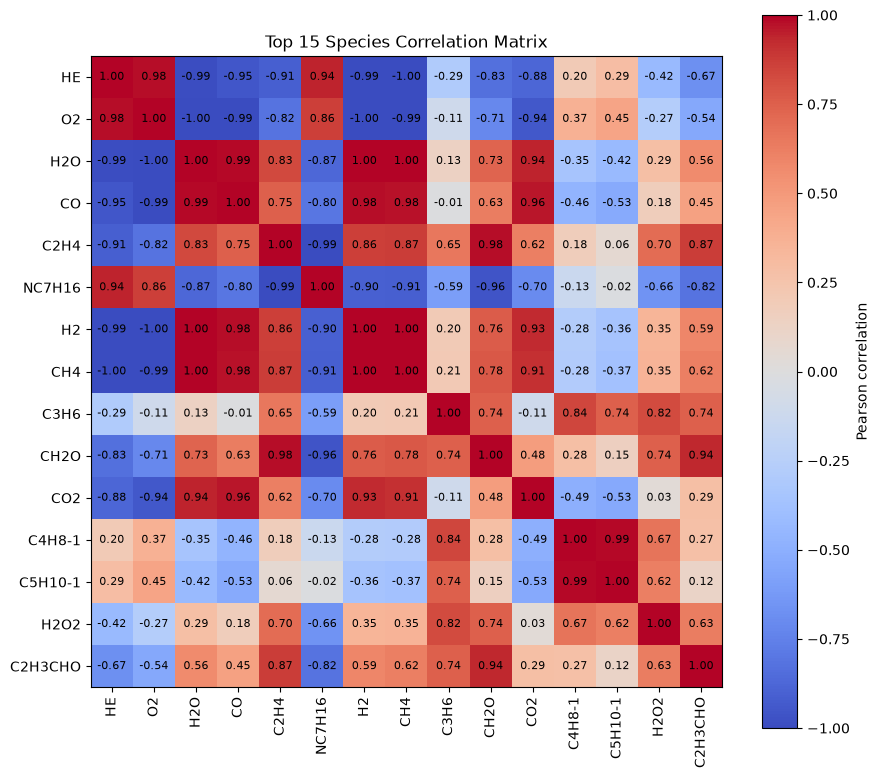

In [10]:
def plot_top_species_correlation(states, n=15, annotate=True):
    x_df = pd.DataFrame(states.X, columns=states.species_names)

    top_species = (
        x_df.mean()
        .sort_values(ascending=False)
        .head(n)
        .index
    )

    corr = x_df[top_species].corr()

    fig, ax = plt.subplots(figsize=(0.4 * n + 3, 0.4 * n + 2))
    image = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")

    ax.set_xticks(range(n), labels=top_species, rotation=90)
    ax.set_yticks(range(n), labels=top_species)

    if annotate:
        for row in range(n):
            for col in range(n):
                ax.text(
                    col,
                    row,
                    f"{corr.iloc[row, col]:.2f}",
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    fig.colorbar(image, ax=ax, label="Pearson correlation")
    ax.set_title(f"Top {n} Species Correlation Matrix")
    fig.tight_layout()
    plt.show()

    return corr

plot_top_species_correlation(states)
pass

In [11]:
X_species = states.X

X_non_species = np.column_stack([
    states.T,
    states.density,
])

X_raw = np.column_stack([
    X_non_species,
    X_species,
])

feature_names = [
    "temperature",
    "density",
    *states.species_names,
]

print("State matrix:", X_raw.shape)
print("Features:", len(feature_names))

State matrix: (347, 1270)
Features: 1270


In [12]:
def pod(y):
    """need to check if this works with nonzero mean"""
    n = len(y)
    y_mean = np.mean(y, axis=0)
    y = y - y_mean
    C = 1 / (n - 1) * y.T @ y
    w, v = np.linalg.eigh(C)
    w = np.flip(w)
    v = np.fliplr(v)
    return y_mean, v

In [13]:
standardizer = Standardizer().fit(X_raw)
X = standardizer.transform(X_raw)
# X = X_raw

sklearn_pca = PCA()
Z_sklearn = sklearn_pca.fit_transform(X)

sklearn_modes = sklearn_pca.components_.T
sklearn_eigenvalues = sklearn_pca.explained_variance_
sklearn_variance_ratio = sklearn_pca.explained_variance_ratio_

In [14]:
pod_mean, pod_modes = pod(X)

X_centered = X - pod_mean
Z_pod = X_centered @ pod_modes

pod_eigenvalues = np.var(Z_pod, axis=0, ddof=1)
pod_variance_ratio = pod_eigenvalues / pod_eigenvalues.sum()

In [15]:
n_compare = min(
    len(sklearn_eigenvalues),
    len(pod_eigenvalues),
)

abs_diff = np.abs(
    sklearn_eigenvalues[:n_compare]
    - pod_eigenvalues[:n_compare]
)

print("Maximum absolute difference:", abs_diff.max())
print("First 10 differences:", abs_diff[:10])

remaining = pod_eigenvalues[len(sklearn_eigenvalues):]

print("Largest remaining eigenvalue:", np.max(np.abs(remaining)))

Maximum absolute difference: 9.1552734e-05
First 10 differences: [9.1552734e-05 1.1444092e-05 7.6293945e-06 9.5367432e-07 6.5565109e-07
 3.5762787e-07 2.6822090e-07 5.2154064e-08 3.1664968e-08 2.2351742e-08]
Largest remaining eigenvalue: 8.8849546e-08


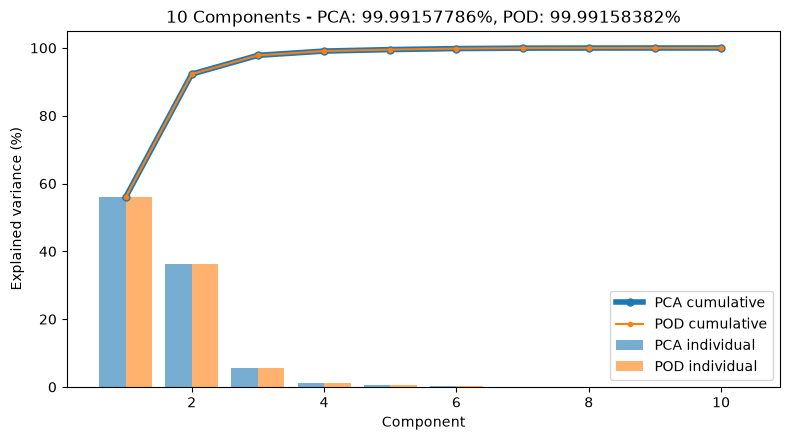

In [16]:
def plot_pca_pod_variance(
    pca: PCA,
    pod_eigenvalues: np.ndarray,
    n_components: int | None = None,
    dpi: int = 100,
    file_path: str | Path | None = None,
) -> tuple[plt.Figure, plt.Axes]:
    """Compare PCA and POD explained variance on one axis."""

    pca_ratio = np.asarray(pca.explained_variance_ratio_)

    pod_eigenvalues = np.asarray(pod_eigenvalues)
    pod_ratio = pod_eigenvalues / pod_eigenvalues.sum()

    n = min(len(pca_ratio), len(pod_ratio))

    if n_components is not None:
        n = min(n, n_components)

    pca_ratio = pca_ratio[:n]
    pod_ratio = pod_ratio[:n]

    components = np.arange(1, n + 1)
    width = 0.4

    fig, ax = plt.subplots(figsize=(8, 4.5), dpi=dpi)

    # Individual explained variance
    ax.bar(
        components - width / 2,
        pca_ratio * 100,
        width=width,
        color="C0",
        alpha=0.6,
        label="PCA individual",
    )
    ax.bar(
        components + width / 2,
        pod_ratio * 100,
        width=width,
        color="C1",
        alpha=0.6,
        label="POD individual",
    )

    # Cumulative explained variance
    ax.plot(
        components,
        np.cumsum(pca_ratio) * 100,
        color="C0",
        marker="o",
        markersize=5,
        lw=4,
        label="PCA cumulative",
    )
    ax.plot(
        components,
        np.cumsum(pod_ratio) * 100,
        color="C1",
        marker="o",
        markersize=3,
        label="POD cumulative",
    )

    ax.set_xlabel("Component")
    ax.set_ylabel("Explained variance (%)")
    ax.set_ylim(0, 105)
    ax.legend()

    pca_cumulative = pca_ratio[:n].sum()
    pod_cumulative = pod_ratio[:n].sum()

    ax.set_title(
        f"{n} Components - "
        f"PCA: {pca_cumulative:.8%}, "
        f"POD: {pod_cumulative:.8%}"
    )

    fig.tight_layout()

    if file_path is not None:
        fig.savefig(file_path, bbox_inches="tight", dpi=dpi)

    return fig, ax

fig, ax = plot_pca_pod_variance(
    pca=sklearn_pca,
    pod_eigenvalues=pod_eigenvalues,
    n_components=10,
)

In [17]:
len(gas.reaction_equations())

5336

In [18]:
time_history.X

array([[ 0.00000000e+00,  0.00000000e+00,  9.67499998e-01, ...,
         4.11971140e-43,  1.37778005e-41,  3.37928758e-30],
       [ 0.00000000e+00,  0.00000000e+00,  9.67499990e-01, ...,
         7.16010857e-38,  2.46920262e-36,  5.71064569e-29],
       [ 0.00000000e+00,  0.00000000e+00,  9.67499966e-01, ...,
         1.62651871e-35,  5.64260611e-34,  4.08399290e-28],
       ...,
       [ 3.55435708e-24,  1.72711779e-29,  9.50368212e-01, ...,
         3.32307771e-13,  1.16011422e-11,  9.56210342e-15],
       [ 4.03901993e-25,  9.51950495e-30,  9.50368209e-01, ...,
         3.32308014e-13,  1.16011507e-11,  9.56211562e-15],
       [-2.06559225e-24,  1.99031347e-30,  9.50368207e-01, ...,
         3.32307896e-13,  1.16011466e-11,  9.56211494e-15]],
      shape=(347, 1268))

In [19]:
print(time_history)
print(len(time_history.component_names))
print(len(time_history.species_names))
print(time_history.extra)
print(time_history)
non_species_components = [
    name
    for name in time_history.component_names
    if
    name not in time_history.species_names
]
print(non_species_components)

       T          D           AR           N2  ...   CVCCVCCJVO      CJVCCVO            t
0    925  0.0724065  0.00000e+00  0.00000e+00  ...  2.12677e-40  3.54146e-29  2.38148e-05
1    925  0.0724065  0.00000e+00  0.00000e+00  ...  3.81152e-35  5.98470e-28  1.21612e-04
2    925  0.0724065  0.00000e+00  0.00000e+00  ...  8.71005e-33  4.27998e-27  3.56264e-04
3    925  0.0724065  0.00000e+00  0.00000e+00  ...  3.53357e-31  2.46839e-26  8.53779e-04
4    925  0.0724065  0.00000e+00  0.00000e+00  ...  2.75296e-29  7.67175e-26  1.35129e-03
..   ...        ...          ...          ...  ...          ...          ...          ...
342  925  0.0711243  5.72349e-24  1.12396e-28  ...  1.82306e-10  1.02016e-13  3.77661e+01
343  925  0.0711243  4.96264e-23  1.02122e-28  ...  1.82306e-10  1.02016e-13  4.05066e+01
344  925  0.0711243  2.75162e-23  9.37580e-29  ...  1.82306e-10  1.02016e-13  4.32472e+01
345  925  0.0711243  3.12683e-24  5.16774e-29  ...  1.82306e-10  1.02016e-13  4.59878e+01
346  925  

### Plot the results

As a test, we plot the mole fraction of CO and see if the simulation has converged. If
not, go back and adjust max. number of steps and/or simulation time.



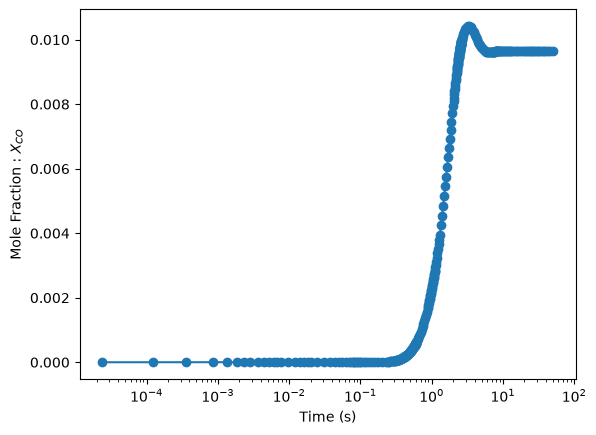

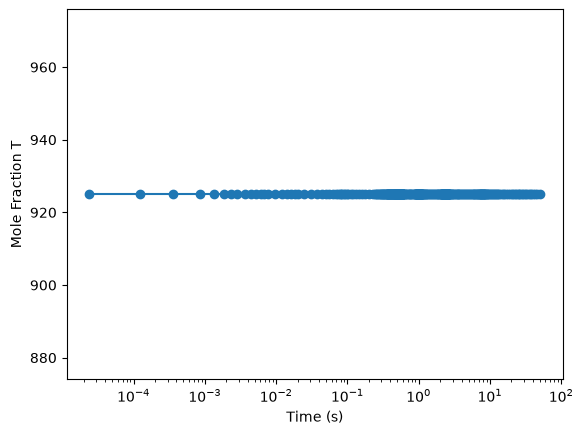

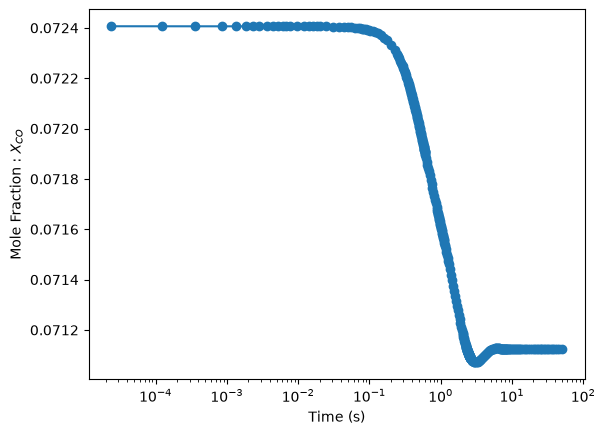

In [20]:
plt.figure()
plt.semilogx(time_history.t, time_history("CO").X, "-o")
plt.xlabel("Time (s)")
plt.ylabel("Mole Fraction : $X_{CO}$")
plt.show()

plt.figure()
plt.semilogx(time_history.t, time_history.T, "-o")
plt.xlabel("Time (s)")
plt.ylabel("Mole Fraction T")
plt.show()

plt.figure()
plt.semilogx(time_history.t, time_history.D, "-o")
plt.xlabel("Time (s)")
plt.ylabel("Mole Fraction : $X_{CO}$")
plt.show()

## Illustration : Modeling experimental data

Let us see if the reactor can reproduce actual experimental measurements.

We first load the data. This is also supplied in the paper by Zhang et al. [1]_ as an
excel sheet



In [21]:
experimental_data_csv = """
T,NC7H16,O2,CO,CO2
500,5.07E-03,2.93E-02,0.00E+00,0.00E+00
525,4.92E-03,2.86E-02,0.00E+00,0.00E+00
550,4.66E-03,2.85E-02,0.00E+00,0.00E+00
575,4.16E-03,2.63E-02,2.43E-04,1.01E-04
600,3.55E-03,2.33E-02,9.68E-04,2.51E-04
625,3.36E-03,2.31E-02,1.42E-03,2.67E-04
650,3.67E-03,2.45E-02,9.16E-04,1.46E-04
675,4.38E-03,2.77E-02,2.25E-04,0.00E+00
700,4.79E-03,2.87E-02,0.00E+00,0.00E+00
725,4.89E-03,2.93E-02,0.00E+00,0.00E+00
750,4.91E-03,2.84E-02,0.00E+00,0.00E+00
775,4.93E-03,2.80E-02,0.00E+00,0.00E+00
800,4.78E-03,2.82E-02,0.00E+00,0.00E+00
825,4.41E-03,2.80E-02,1.49E-05,0.00E+00
850,3.68E-03,2.80E-02,4.18E-04,1.66E-04
875,2.13E-03,2.45E-02,1.65E-03,2.22E-04
900,1.03E-03,2.05E-02,5.51E-03,3.69E-04
925,5.82E-04,1.79E-02,8.59E-03,6.78E-04
950,3.88E-04,1.47E-02,1.05E-02,1.07E-03
975,2.35E-04,1.28E-02,1.19E-02,1.36E-03
1000,1.14E-04,1.16E-02,1.34E-02,1.82E-03
1025,4.83E-05,9.88E-03,1.52E-02,2.41E-03
1050,1.64E-05,8.16E-03,1.83E-02,2.97E-03
1075,1.22E-06,5.48E-03,1.95E-02,3.67E-03
1100,0.00E+00,3.24E-03,2.14E-02,4.38E-03
"""

experimental_data = pd.read_csv(StringIO(experimental_data_csv))
experimental_data.head()

,T,NC7H16,O2,CO,CO2
0,500,0.00507,0.0293,0.000000,0.000000
1,525,0.00492,0.0286,0.000000,0.000000
2,550,0.00466,0.0285,0.000000,0.000000
3,575,0.00416,0.0263,0.000243,0.000101
4,600,0.00355,0.0233,0.000968,0.000251


In [22]:
# Define all the temperatures at which we will run simulations. These should overlap
# with the values reported in the paper as much as possible
T = [650, 700, 750, 775, 825, 850, 875, 925, 950, 1075, 1100]

# Create a SolutionArray to store values for the above points
temp_dependence = ct.SolutionArray(gas)

Now we simply run the reactor code we used above for each temperature



In [23]:
reactor_X = inlet_X

for reactor_temperature in T:
    # Use composition from the previous iteration to speed up convergence
    fuel_air_mixture_tank.phase.TPX = reactor_temperature, reactor_pressure, inlet_X
    stirred_reactor.phase.TPX = reactor_temperature, reactor_pressure, reactor_X

    # Re-run the isothermal simulations
    tic = time.time()
    counter = 0
    reactor_network.initial_time = 0.0
    while reactor_network.time < max_simulation_time:
        reactor_network.step()
        counter += 1
    toc = time.time()
    print(f"Simulation at T={reactor_temperature} K took {toc-tic:3.2f} s to compute "
          f"with {counter} steps")

    reactor_X = stirred_reactor.phase.X
    temp_dependence.append(stirred_reactor.phase.state)

Simulation at T=650 K took 0.55 s to compute with 7 steps
Simulation at T=700 K took 0.47 s to compute with 6 steps
Simulation at T=750 K took 0.41 s to compute with 5 steps
Simulation at T=775 K took 0.33 s to compute with 3 steps
Simulation at T=825 K took 0.33 s to compute with 3 steps
Simulation at T=850 K took 0.28 s to compute with 3 steps
Simulation at T=875 K took 0.21 s to compute with 2 steps
Simulation at T=925 K took 0.29 s to compute with 3 steps
Simulation at T=950 K took 0.28 s to compute with 3 steps
Simulation at T=1075 K took 0.21 s to compute with 2 steps
Simulation at T=1100 K took 0.28 s to compute with 3 steps


### Compare the model results with experimental data



## References

.. [1] K. Zhang, C. Banyon, J. Bugler, H. J. Curran, A. Rodriguez, O. Herbinet, F.
       Battin-Leclerc, C. B'Chir, K. A. Heufer (2016). "An updated experimental and
       kinetic modeling study of n-heptane oxidation," *Combustion and Flame* 172,
       116-135, https://doi.org/10.1016/j.combustflame.2016.06.028.

